In [30]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("OpenCV Version:", cv2.__version__)
print("NumPy Version:", np.__version__)
print("Current Working Directory:", os.getcwd())

OpenCV Version: 5.0.0
NumPy Version: 2.1.3
Current Working Directory: /content


In [31]:
BASE_DIR = "/content/datasets"

print("Dataset path:", BASE_DIR)
print("Dataset exists:", os.path.exists(BASE_DIR))

Dataset path: /content/datasets
Dataset exists: True


In [32]:
classes = ["negative", "positive", "inconclusive"]
splits = ["train", "validation", "test"]

for split in splits:
    for class_name in classes:
        folder_path = os.path.join(BASE_DIR, split, class_name)
        os.makedirs(folder_path, exist_ok=True)

print("Dataset structure created.")

Dataset structure created.


In [33]:
for split in splits:
    for class_name in classes:
        folder_path = os.path.join(BASE_DIR, split, class_name)
        print(folder_path, "->", os.path.exists(folder_path))

/content/datasets/train/negative -> True
/content/datasets/train/positive -> True
/content/datasets/train/inconclusive -> True
/content/datasets/validation/negative -> True
/content/datasets/validation/positive -> True
/content/datasets/validation/inconclusive -> True
/content/datasets/test/negative -> True
/content/datasets/test/positive -> True
/content/datasets/test/inconclusive -> True


In [34]:
dataset_counts = []

for split in splits:
    for class_name in classes:
        folder_path = os.path.join(BASE_DIR, split, class_name)

        image_files = [
            file for file in os.listdir(folder_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ]

        dataset_counts.append({
            "Split": split,
            "Class": class_name,
            "Image_Count": len(image_files)
        })

counts_df = pd.DataFrame(dataset_counts)

print(counts_df)

        Split         Class  Image_Count
0       train      negative           20
1       train      positive           20
2       train  inconclusive           20
3  validation      negative            5
4  validation      positive            5
5  validation  inconclusive            5
6        test      negative            5
7        test      positive            5
8        test  inconclusive            5


In [35]:
def validate_image(image_path):
    image = cv2.imread(image_path)

    if image is None:
        return False, "Unreadable image"

    height, width = image.shape[:2]

    if height < 100 or width < 100:
        return False, "Image resolution too small"

    return True, f"{width}x{height}"


print("Image validation function created.")

Image validation function created.


In [36]:
validation_results = []

for split in splits:
    for class_name in classes:
        folder_path = os.path.join(BASE_DIR, split, class_name)

        image_files = [
            file for file in os.listdir(folder_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ]

        for file in image_files:
            image_path = os.path.join(folder_path, file)

            valid, message = validate_image(image_path)

            validation_results.append({
                "Split": split,
                "Class": class_name,
                "Filename": file,
                "Valid": valid,
                "Details": message
            })

validation_df = pd.DataFrame(validation_results)

if validation_df.empty:
    print("No images found in the dataset.")
else:
    print(validation_df)

    Split         Class              Filename  Valid  Details
0   train      negative      negative_014.png   True  400x300
1   train      negative      negative_003.png   True  400x300
2   train      negative      negative_015.png   True  400x300
3   train      negative      negative_017.png   True  400x300
4   train      negative      negative_013.png   True  400x300
..    ...           ...                   ...    ...      ...
85   test  inconclusive  inconclusive_003.png   True  400x300
86   test  inconclusive  inconclusive_001.png   True  400x300
87   test  inconclusive  inconclusive_005.png   True  400x300
88   test  inconclusive  inconclusive_004.png   True  400x300
89   test  inconclusive  inconclusive_002.png   True  400x300

[90 rows x 5 columns]


In [37]:
print("Dataset Statistics")
print("-" * 40)

for split in splits:
    print(f"\n{split.upper()} SET")

    total = 0

    for class_name in classes:
        folder_path = os.path.join(BASE_DIR, split, class_name)

        image_count = len([
            file for file in os.listdir(folder_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ])

        print(f"{class_name.capitalize():15}: {image_count}")
        total += image_count

    print(f"{'Total':15}: {total}")

Dataset Statistics
----------------------------------------

TRAIN SET
Negative       : 20
Positive       : 20
Inconclusive   : 20
Total          : 60

VALIDATION SET
Negative       : 5
Positive       : 5
Inconclusive   : 5
Total          : 15

TEST SET
Negative       : 5
Positive       : 5
Inconclusive   : 5
Total          : 15


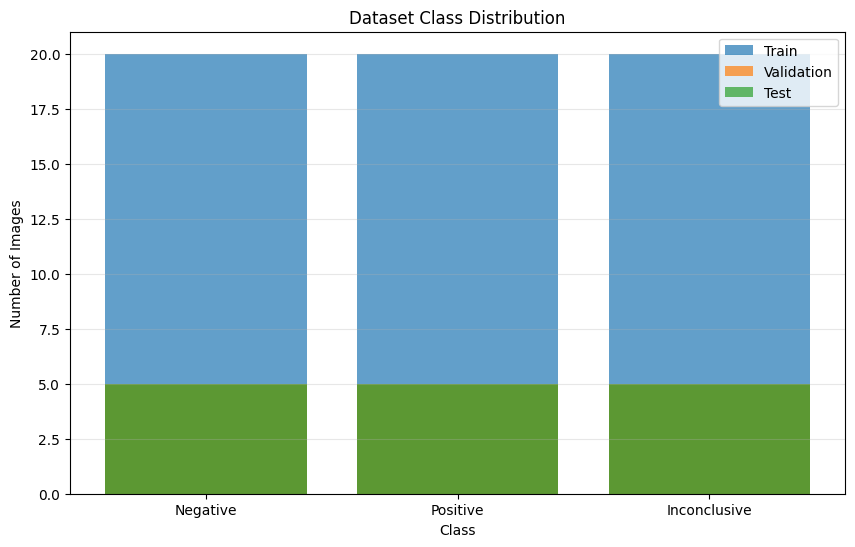

In [38]:
distribution_data = []

for split in splits:
    for class_name in classes:
        folder_path = os.path.join(BASE_DIR, split, class_name)

        image_count = len([
            file for file in os.listdir(folder_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ])

        distribution_data.append({
            "Split": split.capitalize(),
            "Class": class_name.capitalize(),
            "Count": image_count
        })

distribution_df = pd.DataFrame(distribution_data)

plt.figure(figsize=(10, 6))

for split in splits:
    split_name = split.capitalize()
    data = distribution_df[distribution_df["Split"] == split_name]

    plt.bar(
        data["Class"],
        data["Count"],
        alpha=0.7,
        label=split_name
    )

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Dataset Class Distribution")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

In [39]:
import os
import cv2
import numpy as np

np.random.seed(42)

image_size = (300, 400)

samples_per_class = {
    "train": 20,
    "validation": 5,
    "test": 5
}

def create_synthetic_image(class_name):
    image = np.zeros((image_size[0], image_size[1], 3), dtype=np.uint8)

    if class_name == "negative":
        color = (
            np.random.randint(170, 210),
            np.random.randint(170, 210),
            np.random.randint(170, 210)
        )

    elif class_name == "positive":
        color = (
            np.random.randint(40, 80),
            np.random.randint(40, 100),
            np.random.randint(180, 255)
        )

    else:
        color = (
            np.random.randint(100, 160),
            np.random.randint(90, 150),
            np.random.randint(120, 190)
        )

    x1 = np.random.randint(70, 120)
    y1 = np.random.randint(70, 100)
    x2 = np.random.randint(280, 330)
    y2 = np.random.randint(200, 250)

    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        color,
        -1
    )

    noise = np.random.normal(0, 8, image.shape)
    image = np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    return image


for split, count in samples_per_class.items():
    for class_name in classes:

        output_folder = os.path.join(
            BASE_DIR,
            split,
            class_name
        )

        for i in range(count):
            image = create_synthetic_image(class_name)

            filename = f"{class_name}_{i+1:03d}.png"
            image_path = os.path.join(output_folder, filename)

            cv2.imwrite(image_path, image)

print("Synthetic prototype dataset generated.")

Synthetic prototype dataset generated.


In [40]:
dataset_counts = []

for split in splits:
    for class_name in classes:
        folder_path = os.path.join(BASE_DIR, split, class_name)

        image_files = [
            file for file in os.listdir(folder_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ]

        dataset_counts.append({
            "Split": split,
            "Class": class_name,
            "Image_Count": len(image_files)
        })

counts_df = pd.DataFrame(dataset_counts)

print(counts_df)

        Split         Class  Image_Count
0       train      negative           20
1       train      positive           20
2       train  inconclusive           20
3  validation      negative            5
4  validation      positive            5
5  validation  inconclusive            5
6        test      negative            5
7        test      positive            5
8        test  inconclusive            5


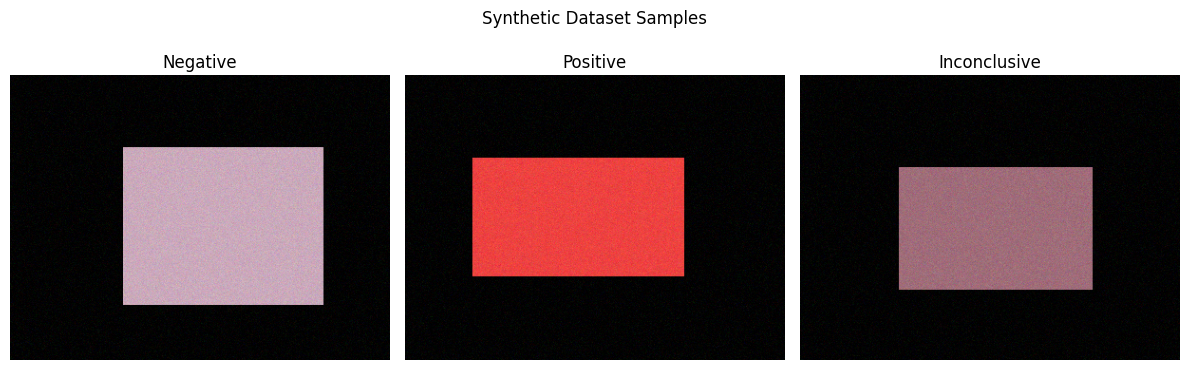

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for index, class_name in enumerate(classes):
    folder_path = os.path.join(BASE_DIR, "train", class_name)

    image_files = [
        file for file in os.listdir(folder_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    image_path = os.path.join(folder_path, image_files[0])
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    axes[index].imshow(image)
    axes[index].set_title(class_name.capitalize())
    axes[index].axis("off")

plt.suptitle("Synthetic Dataset Samples")
plt.tight_layout()
plt.show()

In [42]:
validation_results = []

for split in splits:
    for class_name in classes:
        folder_path = os.path.join(BASE_DIR, split, class_name)

        image_files = [
            file for file in os.listdir(folder_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ]

        for file in image_files:
            image_path = os.path.join(folder_path, file)

            valid, details = validate_image(image_path)

            validation_results.append({
                "Split": split,
                "Class": class_name,
                "Filename": file,
                "Valid": valid,
                "Details": details
            })

validation_df = pd.DataFrame(validation_results)

print("Total images checked:", len(validation_df))
print("Valid images:", validation_df["Valid"].sum())
print("Invalid images:", (~validation_df["Valid"]).sum())

Total images checked: 90
Valid images: 90
Invalid images: 0


In [43]:
dimension_data = []

for split in splits:
    for class_name in classes:
        folder_path = os.path.join(BASE_DIR, split, class_name)

        image_files = [
            file for file in os.listdir(folder_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ]

        for file in image_files:
            image_path = os.path.join(folder_path, file)
            image = cv2.imread(image_path)

            if image is not None:
                height, width = image.shape[:2]

                dimension_data.append({
                    "Split": split,
                    "Class": class_name,
                    "Filename": file,
                    "Width": width,
                    "Height": height
                })

dimensions_df = pd.DataFrame(dimension_data)

print(dimensions_df.head())
print("\nUnique dimensions:")
print(dimensions_df[["Width", "Height"]].drop_duplicates())

   Split     Class          Filename  Width  Height
0  train  negative  negative_014.png    400     300
1  train  negative  negative_003.png    400     300
2  train  negative  negative_015.png    400     300
3  train  negative  negative_017.png    400     300
4  train  negative  negative_013.png    400     300

Unique dimensions:
   Width  Height
0    400     300


In [44]:
quality_data = []

for split in splits:
    for class_name in classes:
        folder_path = os.path.join(BASE_DIR, split, class_name)

        image_files = [
            file for file in os.listdir(folder_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ]

        for file in image_files:
            image_path = os.path.join(folder_path, file)
            image = cv2.imread(image_path)

            if image is None:
                continue

            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

            brightness = np.mean(gray)
            sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()

            quality_data.append({
                "Split": split,
                "Class": class_name,
                "Filename": file,
                "Brightness": brightness,
                "Sharpness": sharpness
            })

quality_df = pd.DataFrame(quality_data)

print(quality_df.head())

print("\nAverage Quality by Class:")
print(
    quality_df.groupby("Class")[["Brightness", "Sharpness"]]
    .mean()
    .round(2)
)

   Split     Class          Filename  Brightness   Sharpness
0  train  negative  negative_014.png   55.042167  702.272848
1  train  negative  negative_003.png   38.397950  590.904123
2  train  negative  negative_015.png   45.252800  666.463741
3  train  negative  negative_017.png   42.174558  650.306658
4  train  negative  negative_013.png   56.777233  756.262175

Average Quality by Class:
              Brightness  Sharpness
Class                              
inconclusive       35.88     482.13
negative           48.93     688.60
positive           30.95     429.31


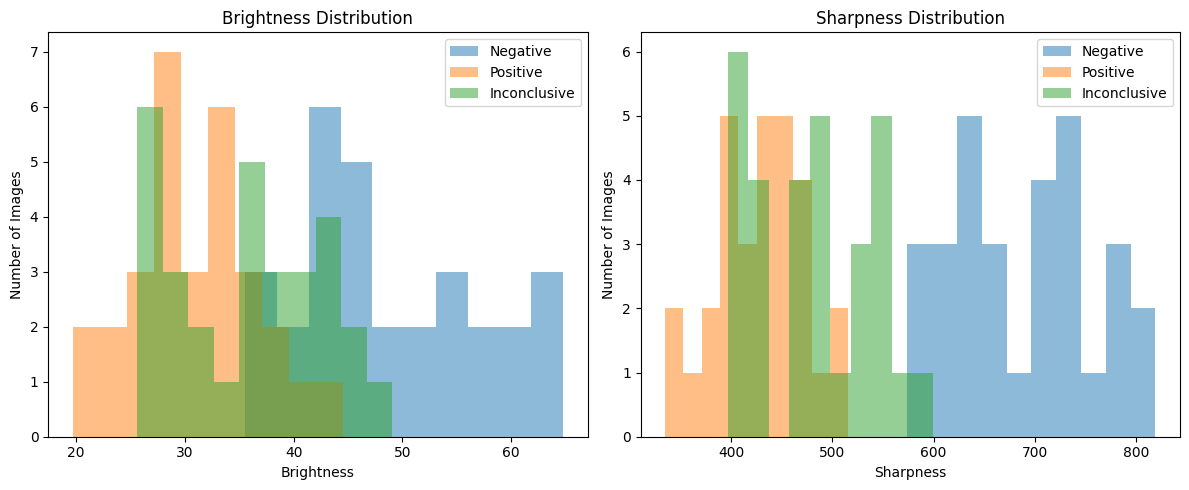

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for class_name in classes:
    class_data = quality_df[quality_df["Class"] == class_name]

    axes[0].hist(
        class_data["Brightness"],
        bins=10,
        alpha=0.5,
        label=class_name.capitalize()
    )

    axes[1].hist(
        class_data["Sharpness"],
        bins=10,
        alpha=0.5,
        label=class_name.capitalize()
    )

axes[0].set_title("Brightness Distribution")
axes[0].set_xlabel("Brightness")
axes[0].set_ylabel("Number of Images")
axes[0].legend()

axes[1].set_title("Sharpness Distribution")
axes[1].set_xlabel("Sharpness")
axes[1].set_ylabel("Number of Images")
axes[1].legend()

plt.tight_layout()
plt.show()

In [46]:
feature_data = []

for split in splits:
    for class_name in classes:
        folder_path = os.path.join(BASE_DIR, split, class_name)

        image_files = [
            file for file in os.listdir(folder_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ]

        for file in image_files:
            image_path = os.path.join(folder_path, file)

            image = cv2.imread(image_path)

            if image is None:
                continue

            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            blurred = cv2.GaussianBlur(gray, (5, 5), 0)

            edges = cv2.Canny(blurred, 50, 150)

            contours, _ = cv2.findContours(
                edges,
                cv2.RETR_EXTERNAL,
                cv2.CHAIN_APPROX_SIMPLE
            )

            valid_contours = [
                contour for contour in contours
                if cv2.contourArea(contour) >= 500
            ]

            if not valid_contours:
                continue

            contour = max(valid_contours, key=cv2.contourArea)

            area = cv2.contourArea(contour)
            perimeter = cv2.arcLength(contour, True)

            x, y, width, height = cv2.boundingRect(contour)

            aspect_ratio = width / height if height != 0 else 0

            hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

            mean_hue = np.mean(hsv[:, :, 0])
            mean_saturation = np.mean(hsv[:, :, 1])
            mean_value = np.mean(hsv[:, :, 2])

            mean_brightness = np.mean(gray)

            feature_data.append({
                "Split": split,
                "Class": class_name,
                "Filename": file,
                "Area": area,
                "Perimeter": perimeter,
                "Width": width,
                "Height": height,
                "Aspect_Ratio": aspect_ratio,
                "Mean_Hue": mean_hue,
                "Mean_Saturation": mean_saturation,
                "Mean_Value": mean_value,
                "Mean_Brightness": mean_brightness
            })

features_df = pd.DataFrame(feature_data)

print("Images with extracted features:", len(features_df))
print("\nFeature dataset shape:", features_df.shape)
print("\nFirst five samples:")
print(features_df.head())

Images with extracted features: 90

Feature dataset shape: (90, 12)

First five samples:
   Split     Class          Filename     Area   Perimeter  Width  Height  \
0  train  negative  negative_014.png  34961.0  817.931020    213     168   
1  train  negative  negative_003.png  24119.0  685.161468    188     132   
2  train  negative  negative_015.png  26965.0  726.132031    199     139   
3  train  negative  negative_017.png  25430.0  728.960458    220     119   
4  train  negative  negative_013.png  33213.0  806.215291    205     166   

   Aspect_Ratio   Mean_Hue  Mean_Saturation  Mean_Value  Mean_Brightness  
0      1.267857  88.694492       157.945267   64.013350        55.042167  
1      1.424242  64.488467       168.632500   43.090175        38.397950  
2      1.431655  75.619942       164.028217   50.608408        45.252800  
3      1.848739  60.880867       168.935267   46.871842        42.174558  
4      1.234940  57.975150       156.024183   61.217567        56.777233  


In [47]:
feature_columns = [
    "Area",
    "Perimeter",
    "Width",
    "Height",
    "Aspect_Ratio",
    "Mean_Hue",
    "Mean_Saturation",
    "Mean_Value",
    "Mean_Brightness"
]

class_feature_means = (
    features_df
    .groupby("Class")[feature_columns]
    .mean()
    .round(2)
)

print("Average CV Features by Class:")
print(class_feature_means)

Average CV Features by Class:
                  Area  Perimeter   Width  Height  Aspect_Ratio  Mean_Hue  \
Class                                                                       
inconclusive  30832.10     779.99  217.90  145.00          1.52     72.84   
negative      29603.23     767.36  213.40  142.87          1.53     68.10   
positive      30402.80     775.63  216.73  143.83          1.53     55.87   

              Mean_Saturation  Mean_Value  Mean_Brightness  
Class                                                       
inconclusive           171.40       45.95            35.88  
negative               162.35       54.57            48.93  
positive               201.14       58.17            30.95  


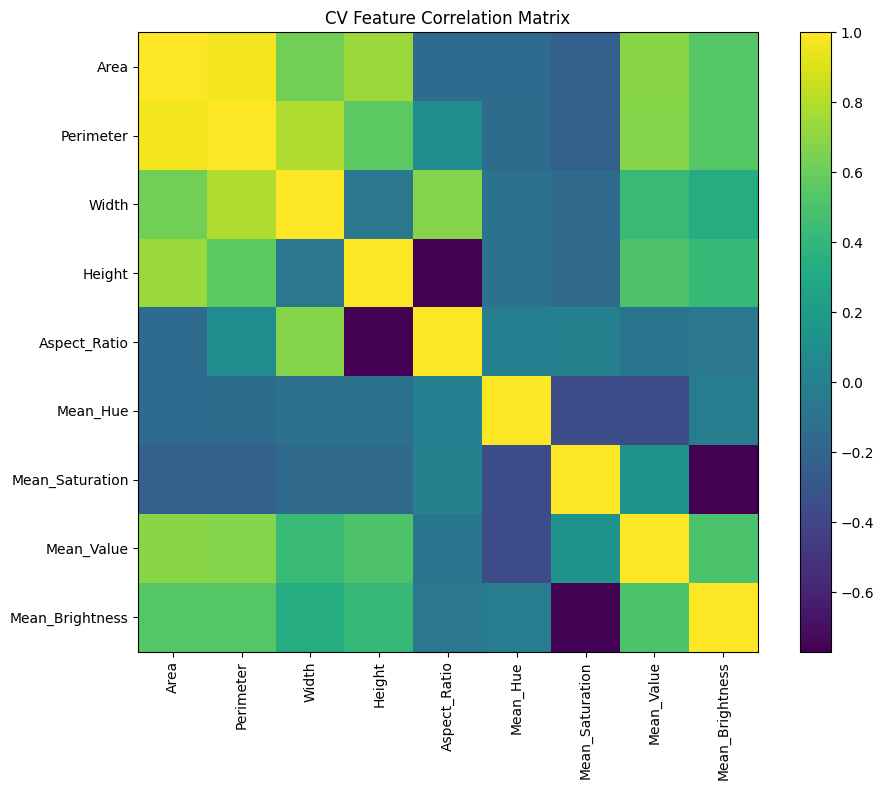

In [48]:
correlation_matrix = features_df[feature_columns].corr()

plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, interpolation="nearest")
plt.colorbar()

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=90
)

plt.yticks(
    range(len(feature_columns)),
    feature_columns
)

plt.title("CV Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [49]:
train_df = features_df[features_df["Split"] == "train"].copy()
validation_df = features_df[features_df["Split"] == "validation"].copy()
test_df = features_df[features_df["Split"] == "test"].copy()

X_train = train_df[feature_columns]
y_train = train_df["Class"]

X_validation = validation_df[feature_columns]
y_validation = validation_df["Class"]

X_test = test_df[feature_columns]
y_test = test_df["Class"]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_validation))
print("Testing samples:", len(X_test))

print("\nFeature shape:")
print("Training:", X_train.shape)
print("Validation:", X_validation.shape)
print("Testing:", X_test.shape)

Training samples: 60
Validation samples: 15
Testing samples: 15

Feature shape:
Training: (60, 9)
Validation: (15, 9)
Testing: (15, 9)


In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")
print("Training shape:", X_train_scaled.shape)
print("Validation shape:", X_validation_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Scaling completed.
Training shape: (60, 9)
Validation shape: (15, 9)
Testing shape: (15, 9)


In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

print("All models trained successfully.")

All models trained successfully.


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

validation_results = []

for name, model in models.items():
    y_pred = model.predict(X_validation_scaled)

    validation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_validation, y_pred),
        "Precision": precision_score(
            y_validation,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_validation,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_validation,
            y_pred,
            average="weighted",
            zero_division=0
        )
    })

validation_results_df = (
    pd.DataFrame(validation_results)
    .sort_values("F1 Score", ascending=False)
    .reset_index(drop=True)
)

print(validation_results_df.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    1.0000     1.0000  1.0000    1.0000
1                  KNN    0.9333     0.9444  0.9333    0.9327
2                  SVM    0.9333     0.9444  0.9333    0.9327
3        Decision Tree    0.7333     0.7460  0.7333    0.7222
4        Random Forest    0.7333     0.8519  0.7333    0.6825


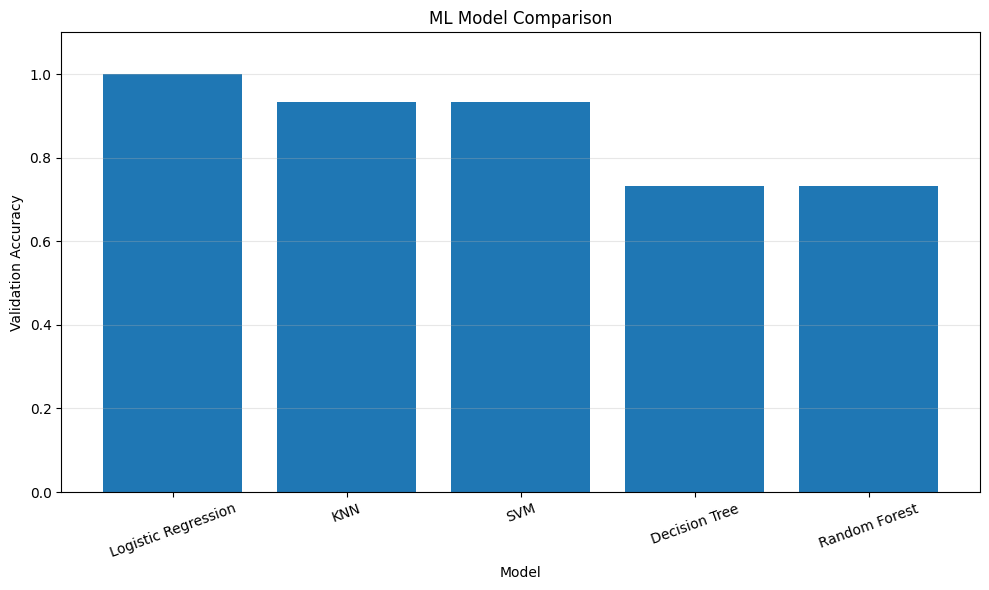

In [53]:
plt.figure(figsize=(10, 6))

plt.bar(
    validation_results_df["Model"],
    validation_results_df["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Validation Accuracy")
plt.title("ML Model Comparison")
plt.ylim(0, 1.1)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

best_model_name = validation_results_df.iloc[0]["Model"]
best_model = models[best_model_name]

y_test_pred = best_model.predict(X_test_scaled)

print("Best Model:", best_model_name)
print()

print("Test Accuracy:",
      accuracy_score(y_test, y_test_pred))

print("Test Precision:",
      precision_score(
          y_test,
          y_test_pred,
          average="weighted",
          zero_division=0
      ))

print("Test Recall:",
      recall_score(
          y_test,
          y_test_pred,
          average="weighted",
          zero_division=0
      ))

print("Test F1 Score:",
      f1_score(
          y_test,
          y_test_pred,
          average="weighted",
          zero_division=0
      ))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)

Best Model: Logistic Regression

Test Accuracy: 1.0
Test Precision: 1.0
Test Recall: 1.0
Test F1 Score: 1.0

Classification Report:
              precision    recall  f1-score   support

inconclusive       1.00      1.00      1.00         5
    negative       1.00      1.00      1.00         5
    positive       1.00      1.00      1.00         5

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



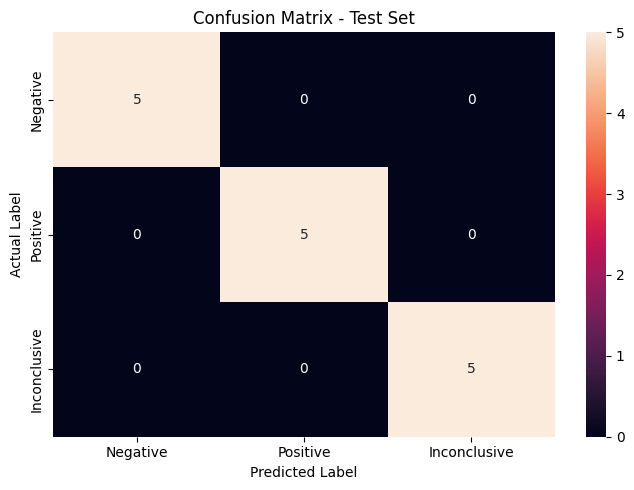

In [55]:
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=["negative", "positive", "inconclusive"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive", "Inconclusive"],
    yticklabels=["Negative", "Positive", "Inconclusive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Test Set")

plt.tight_layout()
plt.show()

In [57]:
import joblib

MODEL_DIR = "/content/models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(
    MODEL_DIR,
    "sih26231_dataset_model.pkl"
)

scaler_path = os.path.join(
    MODEL_DIR,
    "sih26231_dataset_scaler.pkl"
)

joblib.dump(best_model, model_path)
joblib.dump(scaler, scaler_path)

print("Model saved:", model_path)
print("Scaler saved:", scaler_path)

Model saved: /content/models/sih26231_dataset_model.pkl
Scaler saved: /content/models/sih26231_dataset_scaler.pkl


In [58]:
feature_csv_path = "/content/sih26231_cv_features.csv"

features_df.to_csv(
    feature_csv_path,
    index=False
)

print("Feature dataset saved:", feature_csv_path)
print("Rows:", len(features_df))
print("Columns:", len(features_df.columns))

Feature dataset saved: /content/sih26231_cv_features.csv
Rows: 90
Columns: 12
